In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import ExtraTreesRegressor
import joblib

url = "https://drive.google.com/uc?id=1Z7RKmScBO7n9vcDIG3Xeo853Ics4QFaF"
data = pd.read_csv(url)


X = data[["R&D Spend", "Administration", "Marketing Spend"]]
y = data["Profit"]

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
joblib.dump(scaler, "scaler.pkl")

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=7)

models = {
    "Linear Regression": LinearRegression(),
    "Polynomial Regression (degree=2)": make_pipeline(PolynomialFeatures(2), LinearRegression()),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=4),
    "Extra Trees": ExtraTreesRegressor(n_estimators=100, random_state=0)
}

results = {}
best_model = None
best_score = -np.inf
best_model_name = ""

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mean_abs_err = mean_absolute_error(y_test, y_pred)
    mean_squ_err = mean_squared_error(y_test, y_pred)
    root_mean_squ_err = np.sqrt(mean_squ_err)
    r2 = r2_score(y_test, y_pred)

    results[name] = {"MAE": mean_abs_err, "MSE": mean_squ_err, "RMSE": root_mean_squ_err, "R2 Score": r2}

    if r2 > best_score:
        best_score = r2
        best_model = model
        best_model_name = name

joblib.dump(best_model, "best_model.pkl")

print("Model Evaluation Results:\n")
for name, metrics in results.items():
    print(f"{name}")
    for metric, value in metrics.items():
        print(f" {metric}: {value:.4f}")
    print()

print(f"The best model is : {best_model_name} with R² Score of {best_score:.4f}")

Model Evaluation Results:

Linear Regression
 MAE: 6576.2666
 MSE: 69931078.5868
 RMSE: 8362.4804
 R2 Score: 0.9395

Polynomial Regression (degree=2)
 MAE: 8748.2896
 MSE: 114174303.8876
 RMSE: 10685.2377
 R2 Score: 0.9012

KNN Regressor
 MAE: 11865.8581
 MSE: 223275260.5995
 RMSE: 14942.3981
 R2 Score: 0.8068

Extra Trees
 MAE: 5286.2290
 MSE: 56487681.6269
 RMSE: 7515.8287
 R2 Score: 0.9511

The best model is : Extra Trees with R² Score of 0.9511


FileNotFoundError: [Errno 2] No such file or directory: 'static/feature_importance.png'

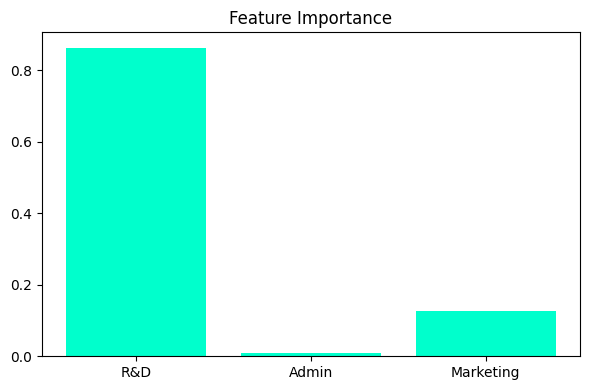

In [ ]:
# train_model.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import os

# Load dataset
url = "https://drive.google.com/uc?id=1Z7RKmScBO7n9vcDIG3Xeo853Ics4QFaF"
data = pd.read_csv(url)

X = data[["R&D Spend", "Administration", "Marketing Spend"]]
y = data["Profit"]

# Scale features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
joblib.dump(scaler, "/content/scaler.pkl")

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)

# Hyperparameter tuning
knn_params = {"n_neighbors": [3, 4, 5, 6]}
extra_params = {"n_estimators": [50, 100, 150]}

knn = GridSearchCV(KNeighborsRegressor(), knn_params, cv=5)
extra = GridSearchCV(ExtraTreesRegressor(random_state=0), extra_params, cv=5)

models = {
    "Linear Regression": LinearRegression(),
    "Polynomial Regression": make_pipeline(PolynomialFeatures(2), LinearRegression()),
    "KNN": knn,
    "Extra Trees": extra
}

best_score = -np.inf
best_model = None
best_name = ""
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    results[name] = {
        "MAE": mean_absolute_error(y_test, preds),
        "MSE": mean_squared_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2": r2
    }
    if r2 > best_score:
        best_score = r2
        best_model = model
        best_name = name

# Save best model
joblib.dump(best_model, "/content/best_model.pkl")

# Feature importance plot
if hasattr(best_model, 'best_estimator_'):
    model_to_use = best_model.best_estimator_
else:
    model_to_use = best_model

if hasattr(model_to_use, "feature_importances_"):
    importances = model_to_use.feature_importances_
    plt.figure(figsize=(6,4))
    plt.bar(["R&D", "Admin", "Marketing"], importances, color="#00ffcc")
    plt.title("Feature Importance")
    plt.tight_layout()
    plt.savefig("static/feature_importance.png")
